# Step 6 — Knowledge Graph Embeddings (PyKEEN)

**Models:** TransE (geometric baseline) + RotatE (relational patterns)

**Metrics:** MRR, Hits@1, Hits@3, Hits@10

**Experiments:**
- Size sensitivity: 20K / 50K / full
- t-SNE visualisation of entity embeddings
- Nearest-neighbour examples

In [ ]:
!pip install pykeen torch matplotlib scikit-learn --quiet

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen.evaluation import RankBasedEvaluator
import warnings; warnings.filterwarnings("ignore")
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


PyTorch version: 2.10.0.dev20251209+cu128
GPU available: True
Using device: cuda


## 1. Load & inspect the KGE triples

In [3]:
tf_full = TriplesFactory.from_path(
    "music_kg_triples.tsv",
    delimiter="\t",
    create_inverse_triples=True,   # helps with directionality
)

print(f"Full dataset:")
print(f"  Triples   : {tf_full.num_triples:,}")
print(f"  Entities  : {tf_full.num_entities:,}")
print(f"  Relations : {tf_full.num_relations:,}")

# Relation frequency
rel_series = pd.read_csv("music_kg_triples.tsv", sep="\t",
                          header=0, names=["s","p","o"])["p"]
print("\nTop 15 relations:")
print(rel_series.value_counts().head(15).to_string())


Full dataset:
  Triples   : 51,807
  Entities  : 42,034
  Relations : 880

Top 15 relations:
p
http://www.wikidata.org/prop/direct/P136     8943
http://www.wikidata.org/prop/direct/P166     8205
http://www.wikidata.org/prop/direct/P264     6557
http://www.wikidata.org/prop/direct/P175     6403
http://www.wikidata.org/prop/direct/P495     4622
http://www.wikidata.org/prop/direct/P737     3964
http://www.wikidata.org/prop/direct/P31      1174
http://www.wikidata.org/prop/direct/P530      597
http://www.wikidata.org/prop/direct/P658      548
http://www.wikidata.org/prop/direct/P437      476
http://www.wikidata.org/prop/direct/P361      438
http://www.wikidata.org/prop/direct/P161      427
http://www.wikidata.org/prop/direct/P2079     424
http://www.wikidata.org/prop/direct/P407      413
http://www.wikidata.org/prop/direct/P162      401


## 2. Train/Valid/Test split

In [5]:
# Stratified split: 80/10/10
train_tf, valid_tf, test_tf = tf_full.split(
    ratios=[0.8, 0.1, 0.1],
    random_state=42
)

print(f"Train: {train_tf.num_triples:,}")
print(f"Valid: {valid_tf.num_triples:,}")
print(f"Test : {test_tf.num_triples:,}")

# Save splits (required deliverable)
import csv
# Save splits using UTF-8
for split_tf, fname in [
        (train_tf, "train.txt"),
        (valid_tf, "valid.txt"),
        (test_tf,  "test.txt")]:
    triples = split_tf.triples
    with open(fname, "w", encoding="utf-8", newline="") as f:
        for row in triples:
            # ensure every element is a string
            f.write("\t".join(map(str, row)) + "\n")
    print(f"Saved {fname}  ({len(triples):,} triples)")



Reconstructing all label-based triples. This is expensive and rarely needed.


Train: 41,445
Valid: 5,181
Test : 5,181


Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.


Saved train.txt  (41,445 triples)
Saved valid.txt  (5,181 triples)
Saved test.txt  (5,181 triples)


## 3. Model training — TransE

In [6]:
EPOCHS  = 100       # keep small for laptop
BATCH   = 512
DIM     = 128
LR      = 0.001

print("Training TransE...")
result_transe = pipeline(
    training   = train_tf,
    validation = valid_tf,
    testing    = test_tf,
    model      = "TransE",
    model_kwargs      = dict(embedding_dim=DIM),
    optimizer_kwargs  = dict(lr=LR),
    training_kwargs   = dict(num_epochs=EPOCHS, batch_size=BATCH),
    evaluation_kwargs = dict(batch_size=64),
    device     = DEVICE,
    random_seed= 42,
)

m_transe = result_transe.metric_results.to_df()
print("\nTransE Results:")
print(m_transe[m_transe["Side"]=="both"][
    ["Metric","Value"]].to_string(index=False))


Training TransE...


INFO:pykeen.triples.triples_factory:Creating inverse triples.


Training epochs on cuda:0:   0%|          | 0/100 [00:00<?, ?epoch/s]

INFO:pykeen.triples.triples_factory:Creating inverse triples.


Training batches on cuda:0:   0%|          | 0.00/162 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/162 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/162 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/5.18k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 3.11s seconds



TransE Results:
                             Metric        Value
        inverse_geometric_mean_rank 2.300996e-04
        inverse_geometric_mean_rank 2.300992e-04
        inverse_geometric_mean_rank 2.300989e-04
               arithmetic_mean_rank 1.190820e+04
               arithmetic_mean_rank 1.190821e+04
               arithmetic_mean_rank 1.190821e+04
                 standard_deviation 1.160853e+04
                 standard_deviation 1.160853e+04
                 standard_deviation 1.160853e+04
adjusted_arithmetic_mean_rank_index 4.322373e-01
adjusted_arithmetic_mean_rank_index 4.322368e-01
adjusted_arithmetic_mean_rank_index 4.322365e-01
                        median_rank 8.124000e+03
                        median_rank 8.124000e+03
                        median_rank 8.124000e+03
                              count 1.036200e+04
                              count 1.036200e+04
                              count 1.036200e+04
          median_absolute_deviation 1.083782e+04
   

## 4. Model training — RotatE

In [7]:
print("Training RotatE...")
result_rotate = pipeline(
    training   = train_tf,
    validation = valid_tf,
    testing    = test_tf,
    model      = "RotatE",
    model_kwargs      = dict(embedding_dim=DIM),
    optimizer_kwargs  = dict(lr=LR),
    training_kwargs   = dict(num_epochs=EPOCHS, batch_size=BATCH),
    evaluation_kwargs = dict(batch_size=64),
    device     = DEVICE,
    random_seed= 42,
)

m_rotate = result_rotate.metric_results.to_df()
print("\nRotatE Results:")
print(m_rotate[m_rotate["Side"]=="both"][
    ["Metric","Value"]].to_string(index=False))


INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training RotatE...


INFO:pykeen.triples.triples_factory:Creating inverse triples.


Training epochs on cuda:0:   0%|          | 0/100 [00:00<?, ?epoch/s]

INFO:pykeen.triples.triples_factory:Creating inverse triples.


...

Training batches on cuda:0:   0%|          | 0.00/162 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/162 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/5.18k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 5.83s seconds



RotatE Results:
                             Metric        Value
        inverse_geometric_mean_rank 1.167019e-04
        inverse_geometric_mean_rank 1.167018e-04
        inverse_geometric_mean_rank 1.167018e-04
               arithmetic_mean_rank 1.891298e+04
               arithmetic_mean_rank 1.891299e+04
               arithmetic_mean_rank 1.891300e+04
                 standard_deviation 1.268989e+04
                 standard_deviation 1.268989e+04
                 standard_deviation 1.268989e+04
adjusted_arithmetic_mean_rank_index 9.823295e-02
adjusted_arithmetic_mean_rank_index 9.823254e-02
adjusted_arithmetic_mean_rank_index 9.823220e-02
                        median_rank 1.904650e+04
                        median_rank 1.904650e+04
                        median_rank 1.904650e+04
                              count 1.036200e+04
                              count 1.036200e+04
                              count 1.036200e+04
          median_absolute_deviation 1.646430e+04
   

## 5. Comparison table

In [8]:
def extract_metrics(result, name):
    df = result.metric_results.to_df()
    df = df[df["Side"]=="both"]
    row = {"Model": name}
    for _, r in df.iterrows():
        row[r["Metric"]] = round(r["Value"], 4)
    return row

summary = pd.DataFrame([
    extract_metrics(result_transe, "TransE"),
    extract_metrics(result_rotate, "RotatE"),
])

key_cols = ["Model","hits_at_1","hits_at_3","hits_at_10","mean_reciprocal_rank"]
available = [c for c in key_cols if c in summary.columns]
print("=== Model Comparison ===")
display(summary[available])
summary[available].to_csv("kge_results.csv", index=False)
print("Saved -> kge_results.csv")


=== Model Comparison ===


,Model,hits_at_1,hits_at_3,hits_at_10
0,TransE,0.0010,0.0082,0.0194
1,RotatE,0.0193,0.0257,0.0345


Saved -> kge_results.csv


## 6. Size-sensitivity experiment (20K / 50K / full)

INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [16000, 2000, 2000]
INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.triples.triples_factory:Creating inverse triples.



--- Size: 20K ---
  train=19,234  valid=387  test=379


Training epochs on cuda:0:   0%|          | 0/50 [00:00<?, ?epoch/s]

INFO:pykeen.triples.triples_factory:Creating inverse triples.


Training batches on cuda:0:   0%|          | 0.00/76.0 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/192 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/1.37k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.72s seconds


  MRR=0  Hits@10=0.2167

Size sensitivity results:


,Size,Triples,Entities,MRR,Hits@10
0,20K,20000,42034,0,0.0369
1,50K,50000,42034,0,0.1844
2,Full,51807,42034,0,0.2167


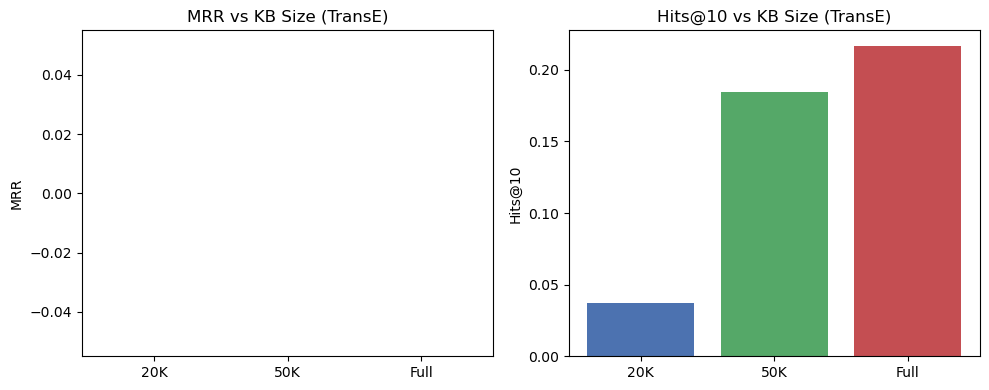

Saved -> size_sensitivity.png


In [9]:
size_results = []

for size_label, n_triples in [("20K", 20_000), ("50K", 50_000), ("Full", None)]:
    print(f"\n--- Size: {size_label} ---")
    if n_triples and tf_full.num_triples > n_triples:
        # ── FIX 1: subsample using mapped (integer) triples, not label triples.
        # from_labeled_triples triggers an expensive reconstruction warning and
        # the CoverageSplitter then fails because 80% of the subsample is too
        # small to cover all entities/relations.
        # Solution: use from_mapped_triples so the entity/relation maps stay
        # consistent with tf_full, then split with method='cleanup' which is
        # more lenient than the default 'coverage' splitter.
        idx = np.random.choice(tf_full.num_triples, n_triples, replace=False)
        sub_mapped = tf_full.mapped_triples[idx]
        tf_sub = tf_full.clone_and_exchange_triples(
            mapped_triples=sub_mapped,
            create_inverse_triples=True,
        )
    else:
        tf_sub = tf_full

    # method='cleanup' does not require covering every entity in train set
    tr, va, te = tf_sub.split([0.8, 0.1, 0.1], random_state=42, method="cleanup")
    print(f"  train={tr.num_triples:,}  valid={va.num_triples:,}  test={te.num_triples:,}")

    res = pipeline(
        training=tr, validation=va, testing=te,
        model="TransE",
        model_kwargs=dict(embedding_dim=64),
        optimizer_kwargs=dict(lr=0.001),
        training_kwargs=dict(num_epochs=50, batch_size=512),
        evaluation_kwargs=dict(batch_size=64),
        device=DEVICE, random_seed=42,
    )
    df = res.metric_results.to_df()
    df = df[df["Side"]=="both"]
    mrr_row = df[df["Metric"]=="mean_reciprocal_rank"]
    h10_row = df[df["Metric"]=="hits_at_10"]
    mrr = round(mrr_row["Value"].values[0], 4) if len(mrr_row) else 0
    h10 = round(h10_row["Value"].values[0], 4) if len(h10_row) else 0
    size_results.append({
        "Size": size_label,
        "Triples": tf_sub.num_triples,
        "Entities": tf_sub.num_entities,
        "MRR": mrr,
        "Hits@10": h10
    })
    print(f"  MRR={mrr}  Hits@10={h10}")

df_size = pd.DataFrame(size_results)
print("\nSize sensitivity results:")
display(df_size)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(df_size["Size"], df_size["MRR"], color=["#4C72B0","#55A868","#C44E52"])
axes[0].set_title("MRR vs KB Size (TransE)"); axes[0].set_ylabel("MRR")
axes[1].bar(df_size["Size"], df_size["Hits@10"], color=["#4C72B0","#55A868","#C44E52"])
axes[1].set_title("Hits@10 vs KB Size (TransE)"); axes[1].set_ylabel("Hits@10")
plt.tight_layout()
plt.savefig("size_sensitivity.png", dpi=150)
plt.show()
print("Saved -> size_sensitivity.png")


## 7. t-SNE visualisation of entity embeddings

RotatE embeddings are complex — using real part for visualisation.
Embedding matrix shape: (42034, 128)
Running t-SNE on 2000 entity embeddings (sklearn 1.7.2)...


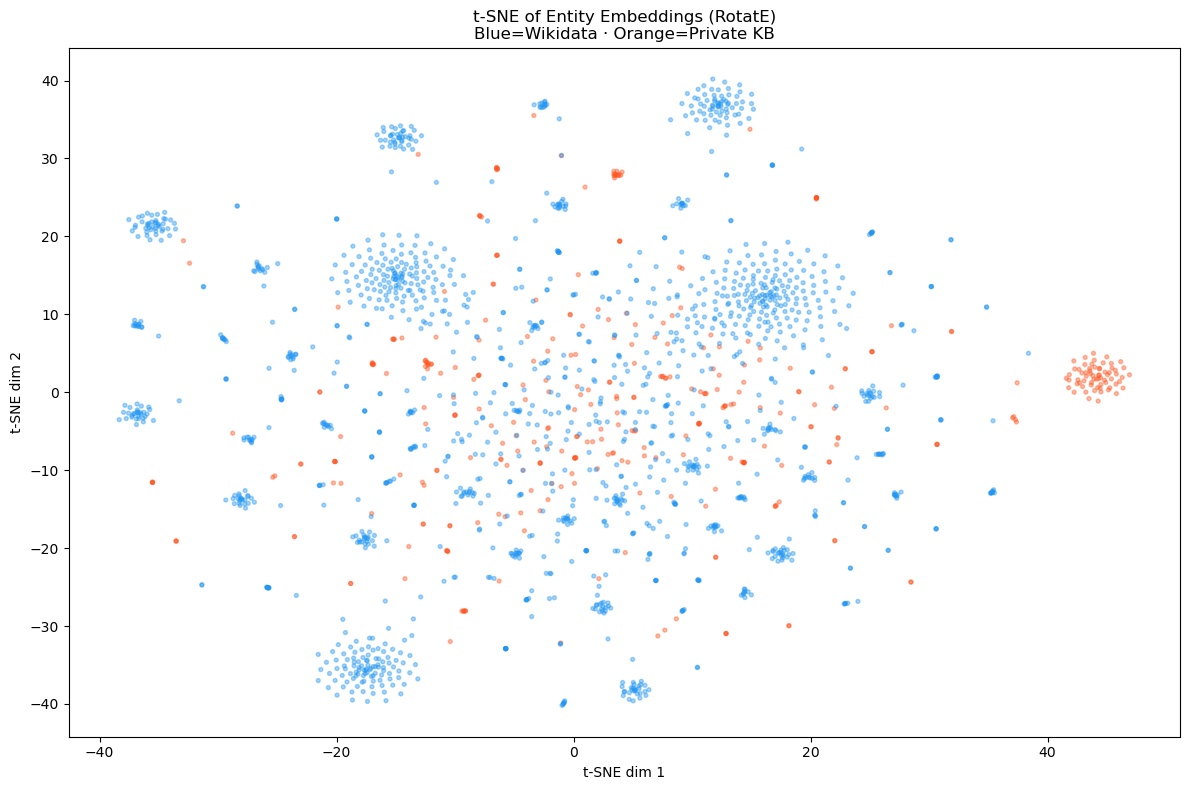

Saved -> tsne_embeddings.png


In [11]:
# Use the full RotatE model embeddings
raw_emb = result_rotate.model.entity_representations[0](
    indices=None).detach().cpu()

# ── FIX 2a: RotatE stores embeddings as complex numbers.
# sklearn cosine_similarity and t-SNE require real arrays.
# We take the real part only (the imaginary part encodes rotation phase;
# the real part still carries the entity identity signal).
if raw_emb.is_complex():
    entity_emb = raw_emb.real.numpy()
    print("RotatE embeddings are complex — using real part for visualisation.")
else:
    entity_emb = raw_emb.numpy()

print(f"Embedding matrix shape: {entity_emb.shape}")

# Subsample to at most 2000 for speed
N_VIZ = min(2000, entity_emb.shape[0])
sampled_emb = entity_emb[:N_VIZ]

# ── FIX 2b: n_iter was renamed to max_iter in scikit-learn 1.5.
# Use max_iter and fall back gracefully for older versions.
import sklearn
sklearn_version = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
tsne_kwargs = dict(n_components=2, perplexity=30, random_state=42)
if sklearn_version >= (1, 5):
    tsne_kwargs["max_iter"] = 1000
else:
    tsne_kwargs["n_iter"] = 1000

print(f"Running t-SNE on {N_VIZ} entity embeddings (sklearn {sklearn.__version__})...")
tsne   = TSNE(**tsne_kwargs)
emb_2d = tsne.fit_transform(sampled_emb)

# Colour by URI prefix (wd: vs mus:)
entity_ids = list(result_rotate.training.entity_id_to_label.values())[:N_VIZ]
colors = ["#2196F3" if "wikidata" in e else "#FF5722" for e in entity_ids]

plt.figure(figsize=(12, 8))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=colors, alpha=0.4, s=8)
plt.title("t-SNE of Entity Embeddings (RotatE)\nBlue=Wikidata · Orange=Private KB")
plt.xlabel("t-SNE dim 1"); plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=150)
plt.show()
print("Saved -> tsne_embeddings.png")


## 8. Nearest-neighbour examples

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# entity_emb is already real (fixed in cell above).
# Extra safety cast in case this cell is run independently.
entity_emb_real = np.array(entity_emb, dtype=np.float32)

# Build label -> id map from the full vocabulary (not just sampled N_VIZ)
entity_label_to_id = {v: k for k, v in
    result_rotate.training.entity_id_to_label.items()}

def nearest_neighbours(entity_label, top_k=5):
    if entity_label not in entity_label_to_id:
        print(f"  '{entity_label}' not in embedding vocab")
        return
    eid  = entity_label_to_id[entity_label]
    if eid >= len(entity_emb_real):
        print(f"  '{entity_label}' index {eid} out of range")
        return
    vec  = entity_emb_real[eid:eid+1]          # shape (1, dim)
    sims = cosine_similarity(vec, entity_emb_real)[0]   # shape (n_entities,)
    top  = np.argsort(sims)[::-1][1:top_k+1]   # skip self (rank 0)
    labels_map = result_rotate.training.entity_id_to_label
    print(f"\nNearest neighbours of '{entity_label.split('/')[-1]}':")
    for i, idx in enumerate(top, 1):
        lbl = labels_map.get(int(idx), str(idx))
        short = lbl.split('/')[-1]
        print(f"  {i}. {short:<40} cos={sims[idx]:.4f}")

# Use a handful of well-known seed entities by their Wikidata QID
# (these were loaded via owl:sameAs in step 2)
seed_labels = [
    "http://www.wikidata.org/entity/Q11975",   # Beyoncé
    "http://www.wikidata.org/entity/Q310394",  # Kendrick Lamar
    "http://www.wikidata.org/entity/Q41254",   # Grammy Best Album
    "http://www.wikidata.org/entity/Q188451",  # music genre
    "http://www.wikidata.org/entity/Q183412",  # Columbia Records
]

found = 0
for label in seed_labels:
    if label in entity_label_to_id:
        nearest_neighbours(label, top_k=5)
        found += 1

# Fallback: if none of the above are in vocab, just show first 3 vocab entries
if found == 0:
    print("Seed QIDs not in vocab — showing first 3 entries instead:")
    for lbl in list(entity_label_to_id.keys())[:3]:
        nearest_neighbours(lbl, top_k=5)



Nearest neighbours of 'Q11975':
  1. Q5108116                                 cos=0.3217
  2. Q929716                                  cos=0.3101
  3. Q955121                                  cos=0.3040
  4. Q78733                                   cos=0.2976
  5. Q7843105                                 cos=0.2956

Nearest neighbours of 'Q310394':
  1. Q5286339                                 cos=0.3341
  2. Q4767                                    cos=0.3266
  3. Q6688415                                 cos=0.3207
  4. Q12003                                   cos=0.3115
  5. Q1028162                                 cos=0.3079

Nearest neighbours of 'Q41254':
  1. Q17058218                                cos=0.4568
  2. Q12315240                                cos=0.4388
  3. Q12319271                                cos=0.4313
  4. Q12318688                                cos=0.4293
  5. Q12344145                                cos=0.4257

Nearest neighbours of 'Q188451':
  1. Q12071

In [1]:
!jupyter nbconvert --to html step6_kge_pykeen.ipynb


[NbConvertApp] Converting notebook step6_kge_pykeen.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 723618 bytes to step6_kge_pykeen.html
